# آموزش مدل تشخیص احساس از متن (BiLSTM)

معماری طبق سند طراحی پروژه: `Embedding -> BiLSTM -> Dense(softmax)` روی ۷ کلاس مشترک با کانال ویژن.

**دیتاست:** [GoEmotions](https://github.com/google-research/google-research/tree/master/goemotions)
(Demszky et al., 2020) — با تاکسونومی Ekman که توسط
[monologg/GoEmotions-pytorch](https://github.com/monologg/GoEmotions-pytorch)
دقیقاً به همون ۷ کلاس پروژه (`angry, disgust, fear, happy, sad, surprise, neutral`)
نگاشت شده.

فقط ردیف‌های تک‌برچسبی استفاده می‌شن (بخش کمی از GoEmotions چندبرچسبیه).

In [1]:
import json
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(0, str(Path.cwd()))
from config import EMOTIONS, WEIGHTS_DIR

tf.random.set_seed(0)
np.random.seed(0)

DATA_DIR = Path.cwd().parent / "dataset_text"
# label index -> project EMOTIONS name, per monologg/GoEmotions-pytorch labels.txt
GOEMOTIONS_EKMAN_LABELS = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

MAX_VOCAB = 20000
MAX_LEN = 30
EMBED_DIM = 100
BATCH_SIZE = 128
EPOCHS = 6

EMOTIONS

I0000 00:00:1788674281.170983     513 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788674295.743828     513 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788674313.941619     513 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

## بارگذاری داده

In [2]:
def load_split(name):
    texts, labels = [], []
    with open(DATA_DIR / name, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 3:
                continue
            text, label_field, _id = parts
            if "," in label_field:  # drop multi-label rows
                continue
            label_name = GOEMOTIONS_EKMAN_LABELS[int(label_field)]
            texts.append(text)
            labels.append(EMOTIONS.index(label_name))
    return texts, labels

train_texts, train_labels = load_split("train.tsv")
dev_texts, dev_labels = load_split("dev.tsv")
test_texts, test_labels = load_split("test.tsv")
print(f"train={len(train_texts)}  dev={len(dev_texts)}  test={len(test_texts)}")

print("\nClass distribution (train):")
for i, e in enumerate(EMOTIONS):
    print(f"  {e:9s} {train_labels.count(i)}")

train=39555  dev=4946  test=4968

Class distribution (train):
  angry     4293
  disgust   498
  fear      541
  happy     15216
  sad       2326
  surprise  3858
  neutral   12823


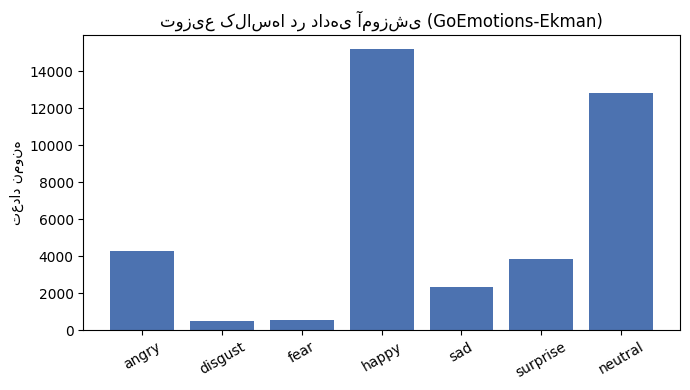

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = [train_labels.count(i) for i in range(len(EMOTIONS))]
ax.bar(EMOTIONS, counts, color="#4C72B0")
ax.set_title("توزیع کلاس‌ها در داده‌ی آموزشی (GoEmotions-Ekman)")
ax.set_ylabel("تعداد نمونه")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## توکنایز کردن و ساخت مدل

In [4]:
tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok.fit_on_texts(train_texts)

def to_padded(texts):
    seqs = tok.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train, y_train = to_padded(train_texts), np.array(train_labels)
X_dev, y_dev = to_padded(dev_texts), np.array(dev_labels)
X_test, y_test = to_padded(test_texts), np.array(test_labels)

vocab_size = min(MAX_VOCAB, len(tok.word_index) + 1)
print("vocab_size:", vocab_size)

vocab_size: 20000


In [5]:
def build_model(vocab_size):
    m = models.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(vocab_size, EMBED_DIM, mask_zero=True),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dropout(0.4),
        layers.Dense(64, activation="relu"),
        layers.Dense(len(EMOTIONS), activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

model = build_model(vocab_size)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,093,191 (7.98 MB)

 Trainable params: 2,093,191 (7.98 MB)

 Non-trainable params: 0 (0.00 B)

## آموزش

دیتاست نامتوازنه (خیلی happy/neutral، خیلی کم fear/disgust) - از class_weight استفاده می‌کنیم.

In [6]:
counts_arr = np.bincount(y_train, minlength=len(EMOTIONS)).astype("float32")
class_weight = {i: float(len(y_train) / (len(EMOTIONS) * max(c, 1))) for i, c in enumerate(counts_arr)}
class_weight

{0: 1.3162623643875122,
 1: 11.346816062927246,
 2: 10.44494342803955,
 3: 0.37136662006378174,
 4: 2.4293699264526367,
 5: 1.464674472808838,
 6: 0.4406702220439911}

In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    verbose=2,
)

Epoch 1/6


E0000 00:00:1788674330.006893     513 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


310/310 - 17s - 54ms/step - accuracy: 0.4079 - loss: 1.6710 - val_accuracy: 0.5063 - val_loss: 1.4011


Epoch 2/6


310/310 - 20s - 64ms/step - accuracy: 0.6134 - loss: 1.0076 - val_accuracy: 0.5780 - val_loss: 1.2124


...

310/310 - 21s - 66ms/step - accuracy: 0.7675 - loss: 0.4940 - val_accuracy: 0.5677 - val_loss: 1.3432


Epoch 5/6


310/310 - 20s - 66ms/step - accuracy: 0.8014 - loss: 0.4016 - val_accuracy: 0.5673 - val_loss: 1.4520


Epoch 6/6


310/310 - 21s - 67ms/step - accuracy: 0.8236 - loss: 0.3434 - val_accuracy: 0.5542 - val_loss: 1.5718


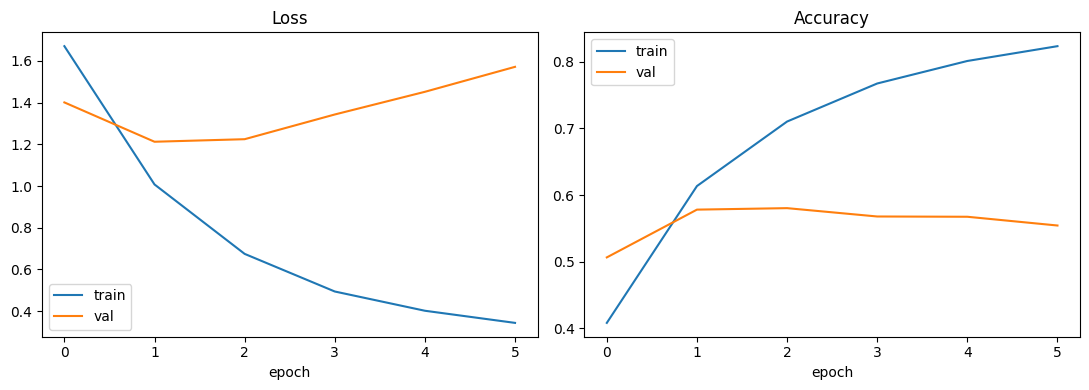

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

## ارزیابی روی داده‌ی تست

In [9]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"test loss={loss:.3f}  test accuracy={acc:.3f}")

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=EMOTIONS, digits=2))

test loss=1.572  test accuracy=0.536


              precision    recall  f1-score   support

       angry       0.33      0.47      0.39       572
     disgust       0.24      0.39      0.30        76
        fear       0.36      0.68      0.47        80
       happy       0.81      0.65      0.72      1863
         sad       0.36      0.50      0.42       283
    surprise       0.34      0.45      0.39       488
     neutral       0.55      0.46      0.50      1606

    accuracy                           0.54      4968
   macro avg       0.43      0.51      0.46      4968
weighted avg       0.58      0.54      0.55      4968



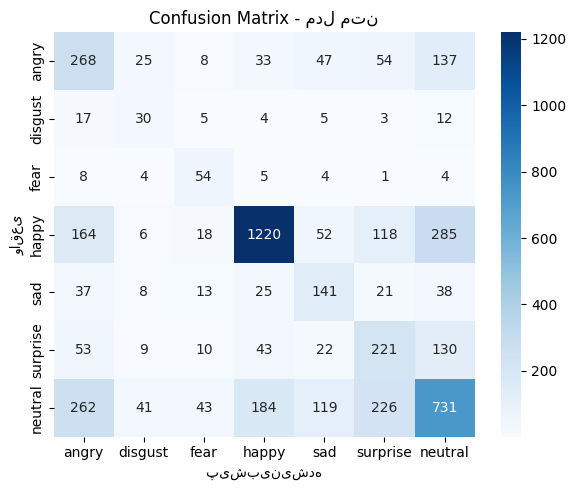

In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax)
ax.set_xlabel("پیش‌بینی‌شده"); ax.set_ylabel("واقعی")
ax.set_title("Confusion Matrix - مدل متن")
plt.tight_layout()
plt.show()

## ذخیره‌ی وزن‌ها

خروجی: `weights/text_emotion.weights.h5` + tokenizer + config — دقیقاً همون فایل‌هایی که `text/text_emotion.py` موقع اجرا لود می‌کنه.

In [11]:
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
model.save_weights(str(WEIGHTS_DIR / "text_emotion.weights.h5"))
with open(WEIGHTS_DIR / "text_tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tok.to_json())
with open(WEIGHTS_DIR / "text_model_config.json", "w", encoding="utf-8") as f:
    json.dump({"vocab_size": vocab_size, "max_len": MAX_LEN, "embed_dim": EMBED_DIM}, f)
print("saved.")

saved.
